# 03 — Customer Analysis

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

### Load Data

In [2]:
customer_df = pd.read_csv('../data/processed/customer_df.csv')

# Purchase Frequency Distribution

In [3]:
orders_per_customer = pd.read_csv('../data/processed/orders_per_customer.csv')

In [4]:
orders_per_customer 

,Customer ID,Number_of_Orders
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1
...,...,...
4333,18280,1
4334,18281,1
4335,18282,2
4336,18283,16


### Distribution Plot
Tail capped at 10+.

Text(0, 0.5, 'Number of Customers ')

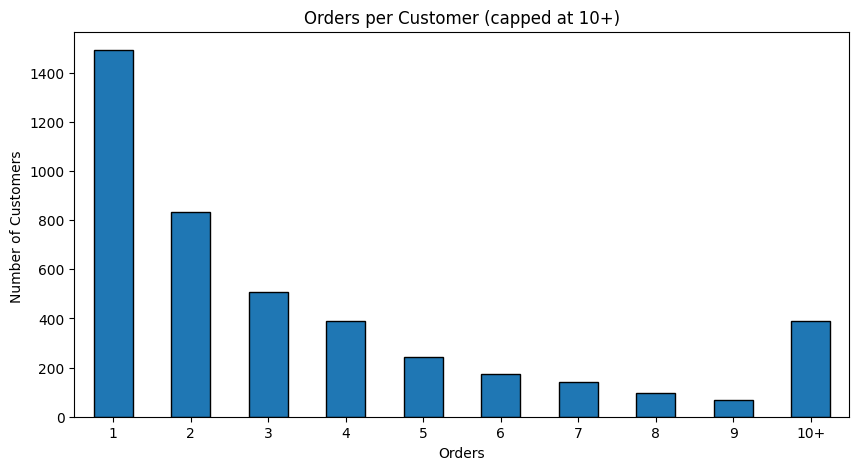

In [5]:
order_dist = orders_per_customer['Number_of_Orders'].clip(upper=10).value_counts().sort_index()
order_dist.index = order_dist.index.astype(str)
order_dist.index = order_dist.index.where(order_dist.index != '10', '10+')

ax = order_dist.plot(
    kind='bar', figsize=(10, 5), edgecolor='black',
    title='Orders per Customer (capped at 10+)', rot=0,
)
ax.set_xlabel('Orders')
ax.set_ylabel('Number of Customers ')

# Repeat vs. One-Time Buyer Behavior

<Axes: title={'center': 'Repeat vs One-time Customers'}, xlabel='is_repeat_customer'>

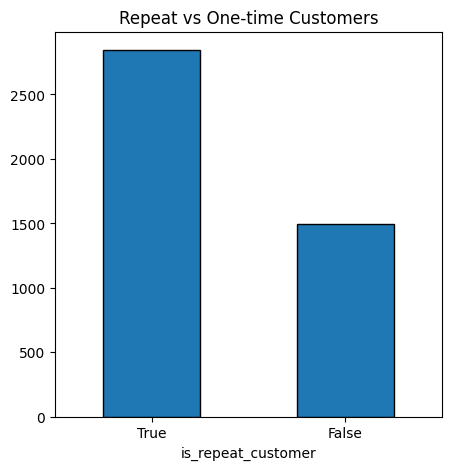

In [6]:
orders_per_customer['is_repeat_customer'] = orders_per_customer['Number_of_Orders'] > 1

orders_per_customer['is_repeat_customer'].value_counts().plot(
    kind='bar',
    figsize=(5, 5),
    edgecolor='black',
    title='Repeat vs One-time Customers',
    rot=0
)

### Compare Spend per Group
Total non-cancelled spend per customer (saved to `revenue_per_customer.csv`, loaded by `05`), then average it by repeat vs. one-time.

In [7]:
revenue_per_customer = (
    customer_df[(~customer_df['is_cancelled']) & (~customer_df['is_zero_value'])]
    .groupby('Customer ID')['total_payment'].sum().reset_index()
)
revenue_per_customer.to_csv('../data/processed/revenue_per_customer.csv', index=False)
revenue_per_customer.sample(5, random_state=0)

,Customer ID,total_payment
2089,15198,193.64
1077,13806,256.38
1495,14388,3212.84
555,13078,12627.94
3825,17584,1242.30


<Axes: title={'center': 'Average Revenue per Customer: Repeat vs One-time'}, xlabel='is_repeat_customer'>

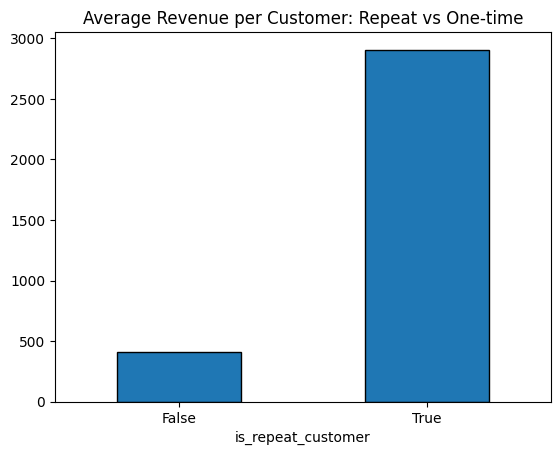

In [8]:
revenue_per_customer = revenue_per_customer.merge(
    orders_per_customer[['Customer ID', 'is_repeat_customer']], on='Customer ID'
)
average_revenue_per_customer = revenue_per_customer.groupby('is_repeat_customer')['total_payment'].mean()
average_revenue_per_customer.plot(
    kind='bar',
    edgecolor='black',
    title='Average Revenue per Customer: Repeat vs One-time',
    rot=0)

### Top Customers by Revenue

In [9]:
top_customers = customer_df[(customer_df['is_cancelled'] == False) & (customer_df['is_zero_value'] == False)].groupby('Customer ID').agg(
    total = ("total_payment" , "sum")).sort_values(by = ["total"], ascending= False)
top_customers.head(10)

,total
Customer ID,
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
14911,143711.17
12415,124914.53
14156,117210.08
17511,91062.38
16029,80850.84


### Top Customers by Order Volume
Top  customers ranked by number of orders.

In [10]:
number_orders = (
    customer_df[(customer_df['is_cancelled'] == False) & (customer_df['is_zero_value'] == False)]
    .groupby('Customer ID')['Invoice']
    .nunique()
    .sort_values(ascending=False)
)
number_orders.head(10)

Customer ID
12748    209
14911    201
17841    124
13089     97
14606     93
15311     91
12971     86
14646     73
16029     63
13408     62
Name: Invoice, dtype: int64

Overlap between the two top-10 lists. Only 3 of the top 10 customers by revenue also appear in the top 10 by order volume --> 14646, 14911, and 16029

This suggests high-value customers split into two different types:(high revenue per order, few orders) and (many orders, lower revenue each)\
Different retention approaches —>  VIP treatment for the former, frequency or loyalty programs for the latter

## Spend by country
Which countries have the most revenue?

Text(0, 0.5, 'Gross Sales (log scale)')

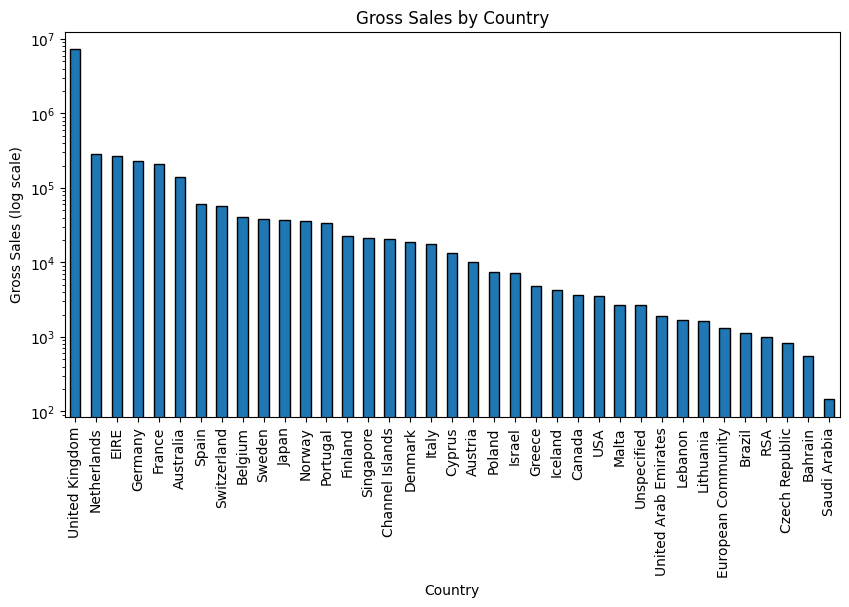

In [11]:
spend_by_country = customer_df[(~customer_df['is_cancelled']) & (~customer_df['is_zero_value'])].groupby('Country')['total_payment'].sum().sort_values(ascending=False)
ax = spend_by_country.plot(kind='bar', edgecolor='black', logy=True, figsize=(10, 5), title='Gross Sales by Country')
ax.set_xlabel('Country')
ax.set_ylabel('Gross Sales (log scale)')

its a uk based company so it's obvious uk has the most revenue

## Number of orders by country
Which countries have the most orders?

Text(0, 0.5, 'Number of Orders (log scale)')

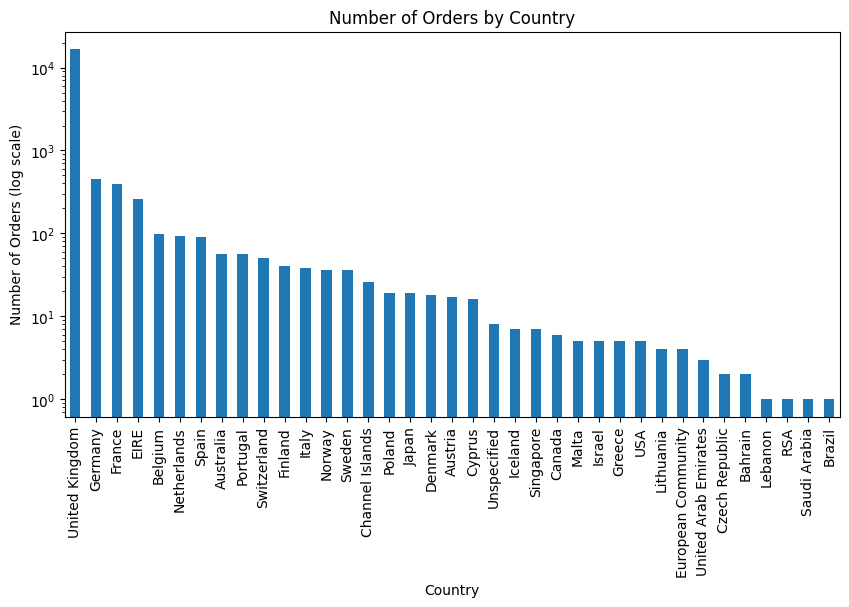

In [12]:
norder_by_country = customer_df[(~customer_df['is_cancelled']) & (~customer_df['is_zero_value'])].groupby('Country')['Invoice'].nunique().sort_values(ascending=False)
ax = norder_by_country.plot(kind='bar', logy=True, figsize=(10, 5), title='Number of Orders by Country')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Orders (log scale)')

## Average order value by country
Are customers in some countries spending more per order?

Text(0, 0.5, 'Average Order Value')

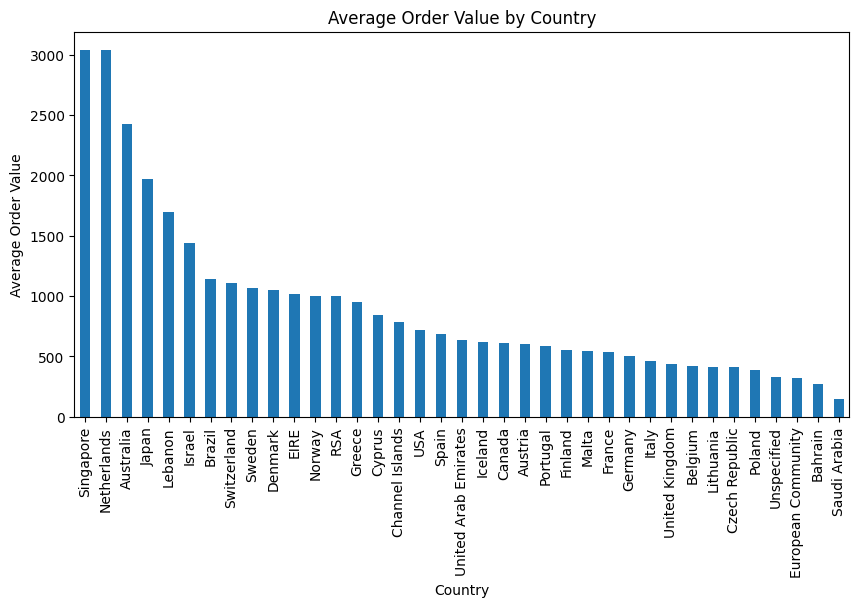

In [13]:
invoice_totals_by_country = customer_df[(~customer_df['is_cancelled']) & (~customer_df['is_zero_value'])].groupby(['Country', 'Invoice'])['total_payment'].sum()
avg_order_by_country = invoice_totals_by_country.groupby('Country').mean().sort_values(ascending=False)
ax = avg_order_by_country.plot(kind='bar', figsize=(10, 5), title='Average Order Value by Country')
ax.set_xlabel('Country')
ax.set_ylabel('Average Order Value')

This is gives us more information, instead of most reveunue we should see based on volume and spent which has more value for us, Singapore have the most avg value.

## Revenue over time

<Axes: title={'center': 'Revenue Over Time'}, xlabel='month'>

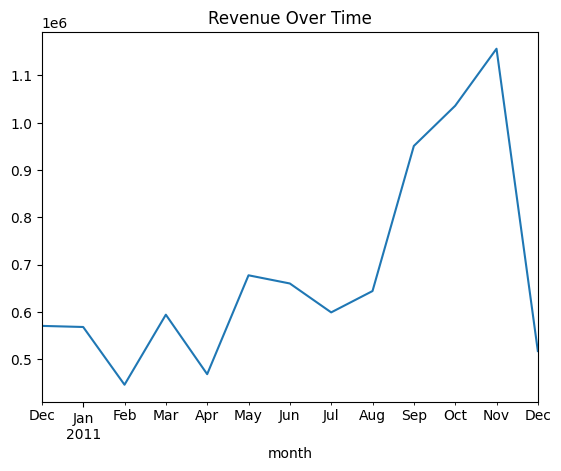

In [14]:
customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'])
customer_df['month'] = customer_df['InvoiceDate'].dt.to_period('M')
revenue_overtime = customer_df[(~customer_df['is_cancelled']) & (~customer_df['is_zero_value'])].groupby('month')['total_payment'].sum()
revenue_overtime.plot(kind='line', title='Revenue Over Time')

revenue is increasing and it rockets at nov, we dont have much data for/after dec so itsprobably normal we see a drop.

## Orders over time
Are people buying more frequently over time?

<Axes: title={'center': 'Orders Over Time'}, xlabel='month'>

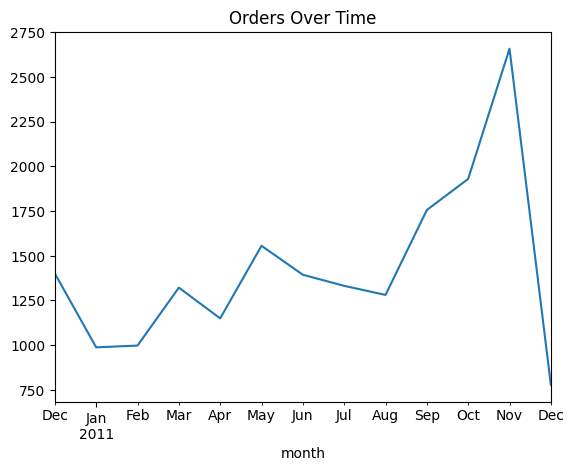

In [15]:
orders_over_time = customer_df[(~customer_df['is_cancelled']) & (~customer_df['is_zero_value'])].groupby('month')['Invoice'].nunique()
orders_over_time.plot(kind='line', title='Orders Over Time')

Orders ramp up in nov/dec so staffing and inventory should scale up through Q4, peaking around November.

## Repeat purchase rate per country

In [16]:
customer_country = customer_df.groupby('Customer ID')['Country'].first()

repeat_by_country = (
    orders_per_customer
    .merge(customer_country, on='Customer ID')
    .groupby('Country')['is_repeat_customer']
    .agg(Total_Customers='count', Repeat_Rate_pct='mean')
)
repeat_by_country['Repeat_Rate_pct'] = (repeat_by_country['Repeat_Rate_pct'] * 100).round(1)

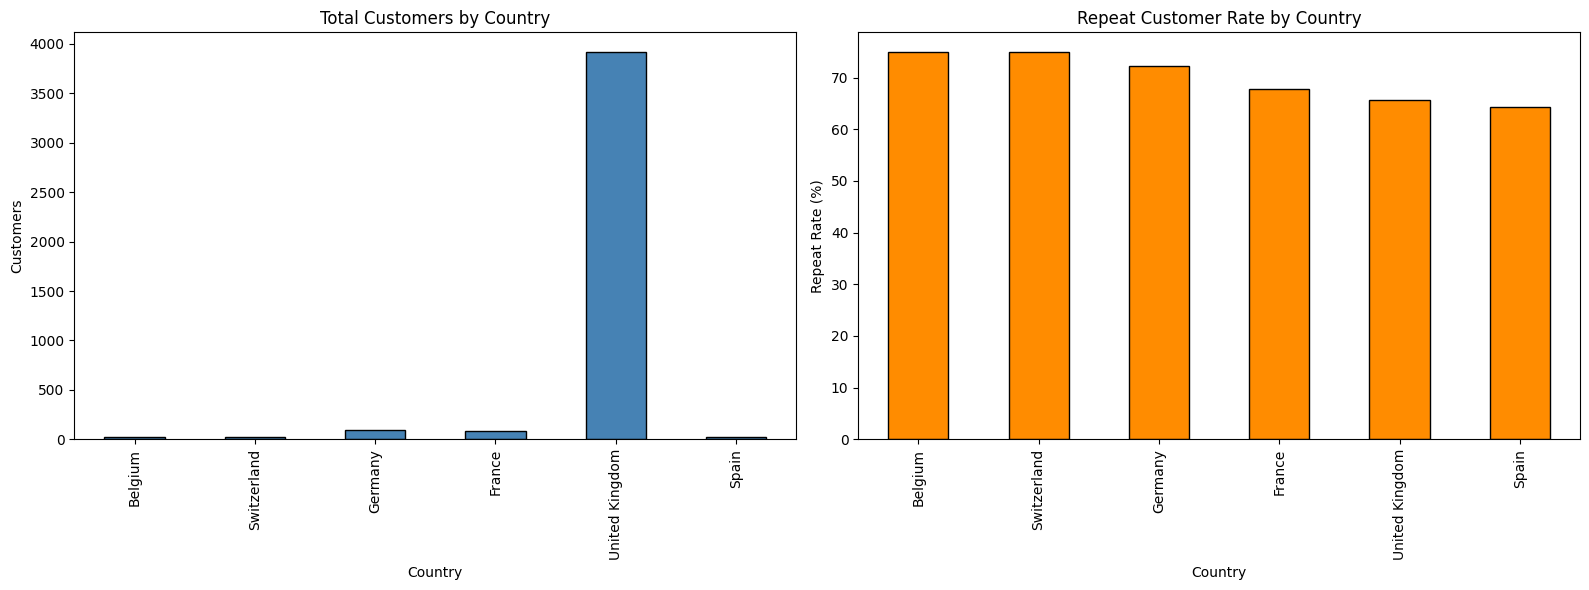

In [17]:
reliable = repeat_by_country[repeat_by_country['Total_Customers'] >= 20].sort_values('Repeat_Rate_pct', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

reliable['Total_Customers'].plot(kind='bar', ax=ax1, edgecolor='black', title='Total Customers by Country', color='steelblue')
ax1.set_xlabel('Country')
ax1.set_ylabel('Customers')

reliable['Repeat_Rate_pct'].plot(kind='bar', ax=ax2, edgecolor='black', title='Repeat Customer Rate by Country', color='darkorange')
ax2.set_xlabel('Country')
ax2.set_ylabel('Repeat Rate (%)')

plt.tight_layout()
plt.show()

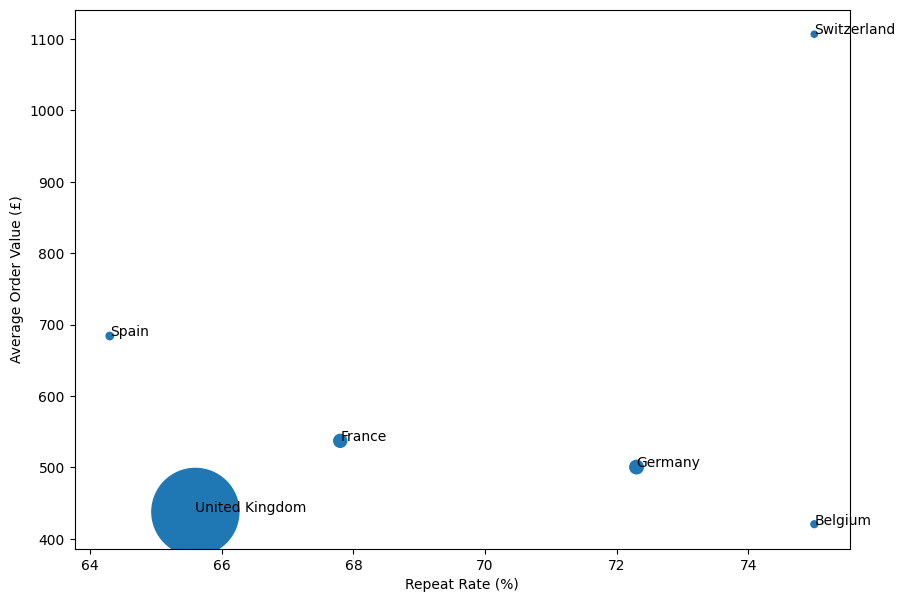

In [18]:
repeat_by_country = repeat_by_country.reset_index()
avg_order_by_country = avg_order_by_country.reset_index()

compare = repeat_by_country.merge(avg_order_by_country, on='Country')
compare = compare[compare['Total_Customers'] >= 20]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(compare['Repeat_Rate_pct'], compare['total_payment'], s=compare['Total_Customers'])

for _, row in compare.iterrows():
    ax.annotate(row['Country'], (row['Repeat_Rate_pct'], row['total_payment']))

ax.set_xlabel('Repeat Rate (%)')
ax.set_ylabel('Average Order Value (£)')
plt.show()

exclude countries with less than 20 customers

## Takeaways

Order counts are heavily skewed: most customers place just 1 order.

Repeat customers are worth far more per person than one-time buyers; it confirms repeat buyers are the more valuable segment to retain.

The business is overwhelmingly UK-based.

International repeat rates beat the UK's across every reliable country we can measure.Those customers stick around and spend more, they're just fewer in number.
International customers make up a small share of the customer base but bring in a much bigger share of revenue .
This points to an acquisition/reach problem, not an operations fix .